# Oxford-IIIT Pet Classification with PyTorch

A small computer vision project exploring a custom CNN and transfer learning with EfficientNet-B0 on the Oxford-IIIT Pet dataset.

Device agnostic code

In [43]:
import torch
from torchvision import datasets
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

Preparing data via `torch.utils.data.DataLoader`

In [44]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt

train_data = datasets.OxfordIIITPet(
    root="data",
    split='trainval',
    download=True,
    transform=transforms.Compose([transforms.Resize((28,28)), transforms.ToTensor(),
                                  transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False) ])
)

test_data = datasets.OxfordIIITPet(
    root="data",
    split='test',
    download=True,
    transform=transforms.Compose([transforms.Resize((28,28)), transforms.ToTensor()])
)

In [45]:
from torch.utils.data import DataLoader
import os

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=64,
    shuffle=True,
    num_workers=os.cpu_count(),
    persistent_workers=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=64,
    shuffle=False,
    num_workers=os.cpu_count(),
    persistent_workers=True
)

In [46]:
class_names = test_data.classes

Visualizing random 8 image from dataset

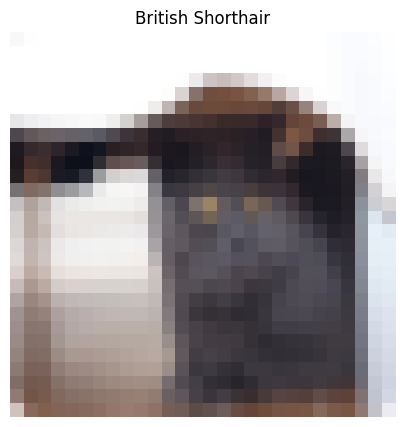

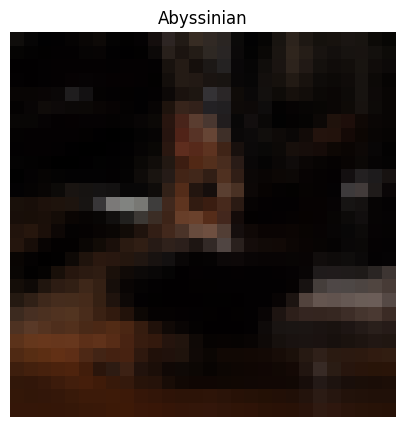

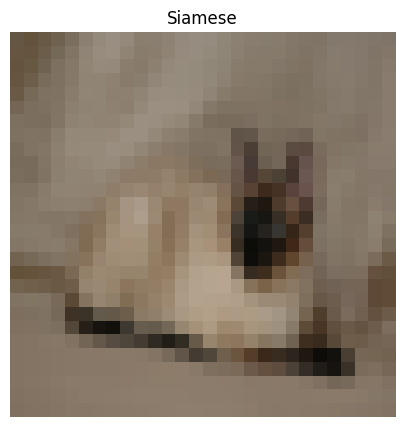

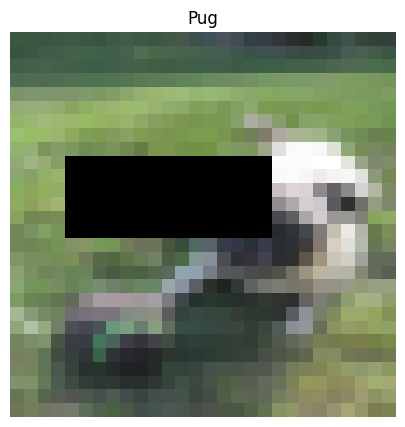

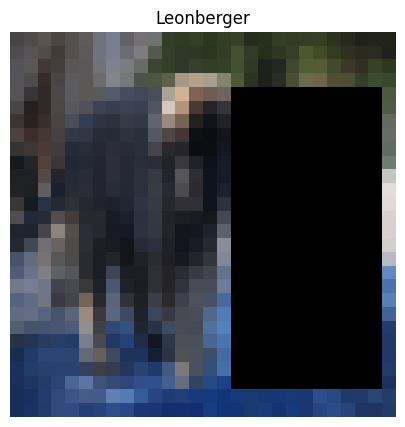

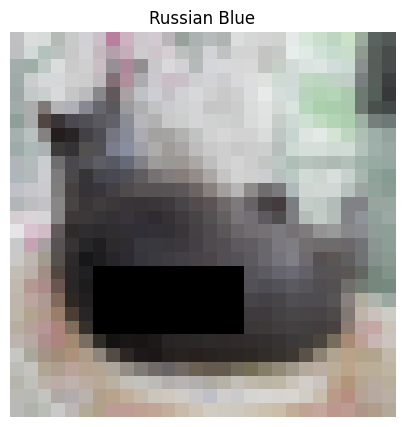

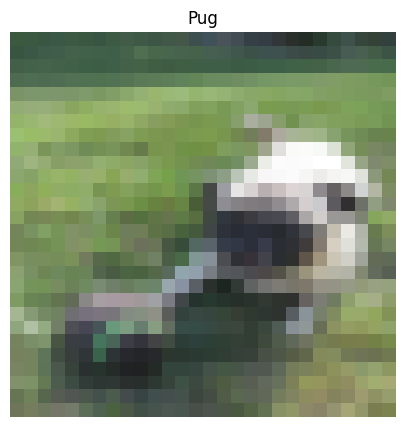

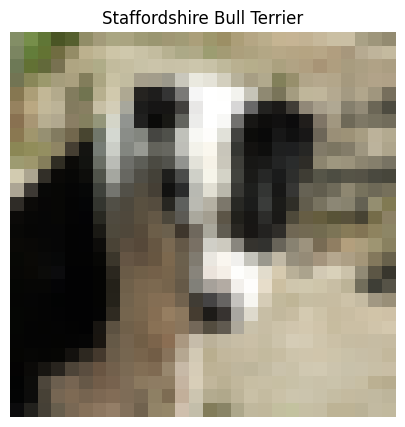

In [47]:
import random
b = [random.randint(0, len(train_data) - 1) for _ in range(8)]
for i in b:
  img, label = train_data[i]
  plt.figure(figsize=(7,5))
  plt.title(class_names[label])
  plt.axis(False)
  plt.imshow(img.permute(1, 2, 0))


In [48]:
train_features, train_labels = next(iter(test_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

Feature batch shape: torch.Size([64, 3, 28, 28])
Labels batch shape: torch.Size([64])


## Building custom CNN
Model architecture copying TinyVGG from: https://poloclub.github.io/cnn-explainer/

In [49]:
from torch import nn

class Baseline_Model(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
      super().__init__()
      self.block_1 = nn.Sequential(
          nn.Conv2d(in_channels=input_shape,
                    out_channels=hidden_units,
                    kernel_size=3,
                    stride=1,
                    padding=1),
          nn.Conv2d(in_channels=hidden_units,
                    out_channels=hidden_units,
                    kernel_size=3,
                    stride=1,
                    padding=1),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2,
                        stride=2)
      )
      self.block_2 = nn.Sequential(
          nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
          nn.ReLU(),
          nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2)
      )
      self.classifier = nn.Sequential(
          nn.Flatten(),
          nn.Linear(in_features=490,
                    out_features=output_shape)
      )

  def forward(self, x: torch.Tensor):
      return self.classifier(self.block_2(self.block_1(x)))


model_0 = Baseline_Model(input_shape=3,
                          hidden_units=10,
                          output_shape=len(class_names)).to(device)
model_0

Baseline_Model(
  (block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=37, bias=True)
  )
)

## Train and test loop function
Calculates loss and accuracy

In [50]:
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in tqdm(range(epochs)):
      print(f"Epoch: {epoch}\n-------")

      model.train()
      train_loss = 0
      train_correct = 0
      train_seen = 0

      for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        # Forward
        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Loss
        train_loss += loss.item()

        # Accuracy
        y_pred_labels = y_pred.argmax(dim=1)
        train_correct += (y_pred_labels == y).sum().item()
        train_seen += len(y)


        if batch % 20 == 0:
            current_loss = train_loss / (batch + 1)
            current_acc = train_correct / train_seen * 100

            print(
                f"Looked at {train_seen}/{len(train_dataloader.dataset)} samples | "
                f"Loss: {current_loss:.4f} | "
                f"Accuracy: {current_acc:.2f}%"
            )

      # Epoch training metrics
      train_loss /= len(train_dataloader)
      train_acc = train_correct / train_seen * 100

      # TESTING
      model.eval()
      test_loss = 0
      test_correct = 0
      test_seen = 0

      with torch.inference_mode():
        for X, y in test_dataloader:
          X, y = X.to(device), y.to(device)

          test_pred = model(X)

          test_loss += loss_fn(test_pred, y).item()

          test_pred_labels = test_pred.argmax(dim=1)
          test_correct += (test_pred_labels == y).sum().item()
          test_seen += len(y)

      test_loss /= len(test_dataloader)
      test_acc = test_correct / test_seen * 100

      print(
          f"\nEpoch {epoch} results | "
          f"Train loss: {train_loss:.4f} | "
          f"Train accuracy: {train_acc:.2f}% | "
          f"Test loss: {test_loss:.4f} | "
          f"Test accuracy: {test_acc:.2f}%\n"
      )

      #  Update results dictionary
      results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
      results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
      results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
      results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results



Train and test loop for custom model

In [51]:
model_0_results =  train(model=model_0,
          train_dataloader=train_dataloader,
          test_dataloader=test_dataloader,
          optimizer=torch.optim.Adam(params=model_0.parameters()),
          loss_fn= nn.CrossEntropyLoss(),
          epochs = 5)
model_0_results

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 64/3680 samples | Loss: 3.6135 | Accuracy: 6.25%
Looked at 1344/3680 samples | Loss: 3.6115 | Accuracy: 2.90%
Looked at 2624/3680 samples | Loss: 3.6102 | Accuracy: 3.43%

Epoch 0 results | Train loss: 3.6061 | Train accuracy: 3.59% | Test loss: 3.5700 | Test accuracy: 5.21%

Epoch: 1
-------
Looked at 64/3680 samples | Loss: 3.5730 | Accuracy: 3.12%
Looked at 1344/3680 samples | Loss: 3.5432 | Accuracy: 5.13%
Looked at 2624/3680 samples | Loss: 3.5346 | Accuracy: 5.56%

Epoch 1 results | Train loss: 3.5181 | Train accuracy: 6.01% | Test loss: 3.4884 | Test accuracy: 6.62%

Epoch: 2
-------
Looked at 64/3680 samples | Loss: 3.5573 | Accuracy: 6.25%
Looked at 1344/3680 samples | Loss: 3.4811 | Accuracy: 6.40%
Looked at 2624/3680 samples | Loss: 3.4677 | Accuracy: 6.71%

Epoch 2 results | Train loss: 3.4382 | Train accuracy: 7.26% | Test loss: 3.4836 | Test accuracy: 6.84%

Epoch: 3
-------
Looked at 64/3680 samples | Loss: 3.4023 | Accuracy: 9.38%
Looked at 13

{'train_loss': [3.606138792531244,
  3.51805003347068,
  3.4381810919991853,
  3.3826794665435265,
  3.3340389235266326],
 'train_acc': [3.5869565217391304,
  6.005434782608695,
  7.255434782608695,
  8.967391304347826,
  9.86413043478261],
 'test_loss': [3.5699535608291626,
  3.488427363593003,
  3.4835693384038993,
  3.457834552074301,
  3.4172005324528136],
 'test_acc': [5.205778141182884,
  6.623058053965658,
  6.841101117470701,
  7.904061052057782,
  8.067593349686565]}

Pretrained EfficientNet model from torchvision with transfer learning.

In [52]:
from torchvision import models

weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights).to(device)

In [53]:
!pip install torchinfo
from torchinfo import summary
# Print a summary using torchinfo
summary(model=model,
        input_size=(32, 3, 224, 224),
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [54]:
auto_transforms = weights.transforms()
train_data_1 = datasets.OxfordIIITPet(
    root="data",
    split='trainval',
    download=True,
    transform=auto_transforms
)

test_data_1 = datasets.OxfordIIITPet(
    root="data",
    split='test',
    download=True,
    transform=auto_transforms
)
train_dataloader_1 = DataLoader(
    dataset=train_data_1,
    batch_size=64,
    shuffle=True,
    num_workers=os.cpu_count(),
    persistent_workers=True
)

test_dataloader_1 = DataLoader(
    dataset=test_data_1,
    batch_size=64,
    shuffle=False,
    num_workers=os.cpu_count(),
    persistent_workers=True
)

In [55]:
# only trained classifier layer
#for param in model.features.parameters():
  #param.requires_grad = False

In [56]:
# the final feature layers are also trained -> fine tuning
for param in model.features[:-2].parameters():
    param.requires_grad = False

In [57]:
model.classifier = nn.Sequential(
                    nn.Dropout(p=0.2, inplace=True),
                    nn.Linear(in_features=1280, out_features=len(class_names), bias=True))
model = model.to(device)

In [58]:
!pip install torchinfo
from torchinfo import summary

summary(model=model,
        input_size=(32, 3, 224, 224),
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 37]             --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   Partial
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32

Training for EfficientNet and saving results.

In [59]:
model_efficientnet_results =  train(model=model,
          train_dataloader=train_dataloader_1,
          test_dataloader=test_dataloader_1,
          optimizer=torch.optim.Adam(params=model.parameters()),
          loss_fn= nn.CrossEntropyLoss(),
          epochs = 5)
model_efficientnet_results

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 64/3680 samples | Loss: 3.6165 | Accuracy: 0.00%
Looked at 1344/3680 samples | Loss: 2.3181 | Accuracy: 49.63%
Looked at 2624/3680 samples | Loss: 1.6108 | Accuracy: 63.11%

Epoch 0 results | Train loss: 1.2967 | Train accuracy: 69.10% | Test loss: 0.4352 | Test accuracy: 86.78%

Epoch: 1
-------
Looked at 64/3680 samples | Loss: 0.2736 | Accuracy: 92.19%
Looked at 1344/3680 samples | Loss: 0.3210 | Accuracy: 91.22%
Looked at 2624/3680 samples | Loss: 0.3130 | Accuracy: 91.04%

Epoch 1 results | Train loss: 0.3011 | Train accuracy: 91.28% | Test loss: 0.4008 | Test accuracy: 87.11%

Epoch: 2
-------
Looked at 64/3680 samples | Loss: 0.1434 | Accuracy: 96.88%
Looked at 1344/3680 samples | Loss: 0.1523 | Accuracy: 96.50%
Looked at 2624/3680 samples | Loss: 0.1642 | Accuracy: 95.81%

Epoch 2 results | Train loss: 0.1667 | Train accuracy: 95.52% | Test loss: 0.4283 | Test accuracy: 86.84%

Epoch: 3
-------
Looked at 64/3680 samples | Loss: 0.1355 | Accuracy: 96.8

{'train_loss': [1.2966819343895748,
  0.30106671796790485,
  0.16669120588179293,
  0.10451794505633157,
  0.06524807147296338],
 'train_acc': [69.10326086956522,
  91.27717391304347,
  95.5163043478261,
  97.44565217391305,
  98.36956521739131],
 'test_loss': [0.4352100097156804,
  0.4007830339451802,
  0.42832232863995534,
  0.39388493310403205,
  0.40435044181629504],
 'test_acc': [86.78113927500681,
  87.10820387026438,
  86.83565004088307,
  87.6805669119651,
  88.00763150722267]}

In [60]:
from typing import Dict, List
import matplotlib.pyplot as plt

def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(10, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

## Plotting the results

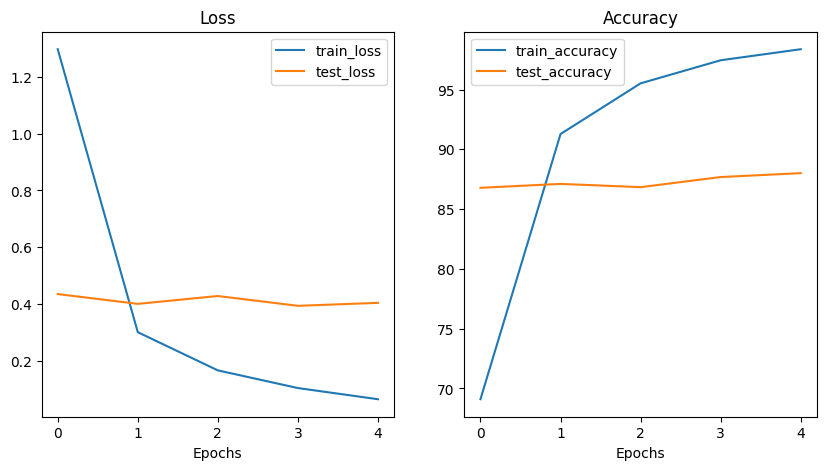

In [61]:
plot_loss_curves(model_efficientnet_results)

Training accuracy approached 99%, while test accuracy remained around 86%, indicating substantial overfitting despite the use of transfer learning.

## Saving and loading the model

In [62]:
import os
path = "models"
try:
    os.mkdir(path)
except FileExistsError:
    print("Directory already exists.")

Directory already exists.


In [63]:
PATH = "models/efficient_model.pkl"
torch.save(model.state_dict(), PATH)

model_1 = models.efficientnet_b0(weights=None).to(device)
model_1.classifier = nn.Sequential(
                    nn.Dropout(p=0.2, inplace=True),
                    nn.Linear(in_features=1280, out_features=len(class_names), bias=True))
model_1 = model_1.to(device)
summary(model=model_1,
        input_size=(32, 3, 224, 224),
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 37]             --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [64]:
model_1.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

## Make a prediction on a custom image

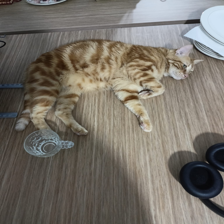

In [65]:
import requests
from PIL import Image

url = "https://raw.githubusercontent.com/feyzanurkuzuoglu/AI-portfolio/main/oxford_pet_efficientnet/kedi.jpeg"
response = requests.get(url)

with open("kedi.jpeg", "wb") as f:
    f.write(response.content)

img = Image.open("kedi.jpeg")
img = img.resize((224,224))
img

In [66]:
img = auto_transforms(img)

In [67]:
model_1.eval()
y_pred_logit = model_1(img.unsqueeze(0).to(device))

In [68]:
y_pred_label = torch.argmax(torch.softmax(y_pred_logit, dim=1), dim=1)
y_pred_label

tensor([5], device='cuda:0')

In [69]:
class_names[y_pred_label.item()]

'Bengal'